pip install tensorflow

In [3]:
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

In [5]:
digitos = load_digits()
digitos

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [9]:
digitos.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [10]:
digitos.data[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

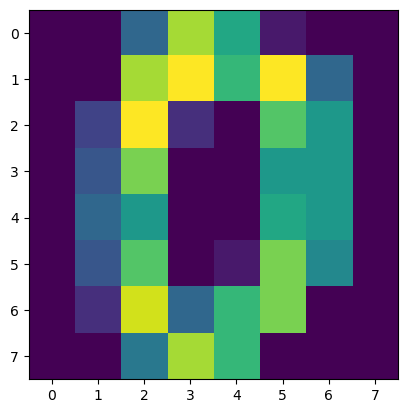

In [12]:
plt.imshow(digitos.data[0].reshape(8,8))

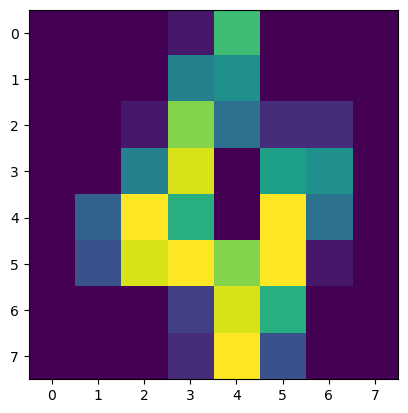

In [14]:
plt.imshow(digitos.images[4])

In [15]:
X = digitos.data

In [16]:
X = X / 16.0

In [17]:
X_entrena, X_prueba = train_test_split(X, test_size=0.2, random_state=42, )

In [18]:
imagen_entrada = Input(shape=(64, ))

In [21]:
codificado = Dense(32, activation='relu') (imagen_entrada)
codificado

<KerasTensor: shape=(None, 32) dtype=float32 (created by layer 'dense_2')>

In [22]:
decodificado = Dense(64, activation='sigmoid') (codificado)
decodificado

<KerasTensor: shape=(None, 64) dtype=float32 (created by layer 'dense_3')>

In [24]:
autoencoder = Model(imagen_entrada, decodificado)
autoencoder

In [25]:
autoencoder.compile(optimizer='adam',
    loss='binary_crossentropy')

In [27]:
autoencoder.fit(X_entrena,X_entrena, epochs=100, batch_size=256, shuffle=True, validation_data=(X_prueba,X_prueba))

Epoch 1/100
6/6 [==============================] - 0s 38ms/step - loss: 0.2677 - val_loss: 0.2701
Epoch 2/100
6/6 [==============================] - 0s 9ms/step - loss: 0.2673 - val_loss: 0.2697
Epoch 3/100
6/6 [==============================] - 0s 8ms/step - loss: 0.2669 - val_loss: 0.2693
Epoch 4/100
6/6 [==============================] - 0s 8ms/step - loss: 0.2666 - val_loss: 0.2689
Epoch 5/100
6/6 [==============================] - 0s 7ms/step - loss: 0.2662 - val_loss: 0.2685
Epoch 6/100
6/6 [==============================] - 0s 8ms/step - loss: 0.2658 - val_loss: 0.2682
Epoch 7/100
6/6 [==============================] - 0s 8ms/step - loss: 0.2654 - val_loss: 0.2678
Epoch 8/100
6/6 [==============================] - 0s 8ms/step - loss: 0.2651 - val_loss: 0.2675
Epoch 9/100
6/6 [==============================] - 0s 7ms/step - loss: 0.2647 - val_loss: 0.2671
Epoch 10/100
6/6 [==============================] - 0s 8ms/step - loss: 0.2644 - val_loss: 0.2668
Epoch 11/100
6/6 [==========

6/6 [==============================] - 0s 8ms/step - loss: 0.2488 - val_loss: 0.2511
Epoch 85/100
6/6 [==============================] - 0s 7ms/step - loss: 0.2487 - val_loss: 0.2510
Epoch 86/100
6/6 [==============================] - 0s 7ms/step - loss: 0.2486 - val_loss: 0.2508
Epoch 87/100
6/6 [==============================] - 0s 7ms/step - loss: 0.2485 - val_loss: 0.2507
Epoch 88/100
6/6 [==============================] - 0s 7ms/step - loss: 0.2483 - val_loss: 0.2506
Epoch 89/100
6/6 [==============================] - 0s 7ms/step - loss: 0.2482 - val_loss: 0.2505
Epoch 90/100
6/6 [==============================] - 0s 7ms/step - loss: 0.2481 - val_loss: 0.2503
Epoch 91/100
6/6 [==============================] - 0s 7ms/step - loss: 0.2480 - val_loss: 0.2502
Epoch 92/100
6/6 [==============================] - 0s 8ms/step - loss: 0.2478 - val_loss: 0.2501
Epoch 93/100
6/6 [==============================] - 0s 7ms/step - loss: 0.2477 - val_loss: 0.2500
Epoch 94/100
6/6 [===============

12/12 [==============================] - 0s 912us/step


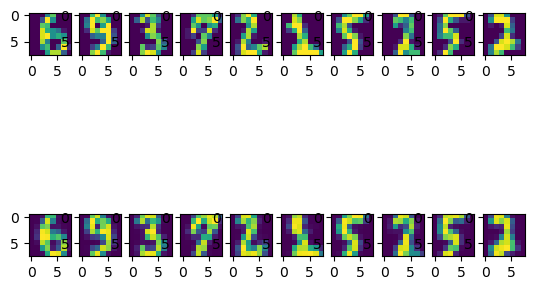

In [33]:
for i in range (10):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_prueba[i].reshape(8,8))
    
    plt.subplot(2, 10, i+1+10)
    plt.imshow(autoencoder.predict(X_prueba)[i].reshape(8,8))

In [6]:
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

In [11]:
digits = load_digits()

X= digits.data

In [12]:
X = X /16.0

array([[0.    , 0.    , 0.3125, ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.625 , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 1.    , 0.5625, 0.    ],
       ...,
       [0.    , 0.    , 0.0625, ..., 0.375 , 0.    , 0.    ],
       [0.    , 0.    , 0.125 , ..., 0.75  , 0.    , 0.    ],
       [0.    , 0.    , 0.625 , ..., 0.75  , 0.0625, 0.    ]],
      shape=(1797, 64))

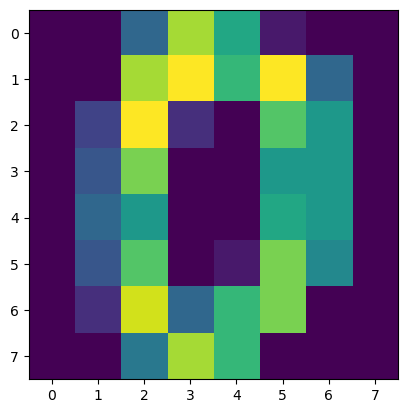

In [18]:
plt.imshow(X[0].reshape(8,8))

In [21]:
X_train, X_test = train_test_split(X, random_state=42, train_size=0.7)
Image = Input(shape = (64, ))

In [24]:
cod = Dense(32, activation='relu') (Image)
cod

<KerasTensor shape=(None, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>

In [27]:
decod = Dense (64, activation= 'softmax') (cod) 

In [28]:
autoencoder = Model(Image, decod)
autoencoder

<Functional name=functional, built=True>

In [29]:
autoencoder.compile(optimizer='adam',
    loss='binary_crossentropy')

In [32]:
autoencoder.fit(X_train,X_train, epochs=100, batch_size=256, shuffle=True, validation_data=(X_test,X_test))

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.6959 - val_loss: 0.6879
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6825 - val_loss: 0.6756
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6699 - val_loss: 0.6629
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6562 - val_loss: 0.6478
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6396 - val_loss: 0.6292
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6191 - val_loss: 0.6065
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5947 - val_loss: 0.5803
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5672 - val_loss: 0.5522
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5388 - val_loss: 0.5249
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5122 - val_loss: 0.5005
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4890 - val_loss: 0.4801
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4700 - val_lo

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


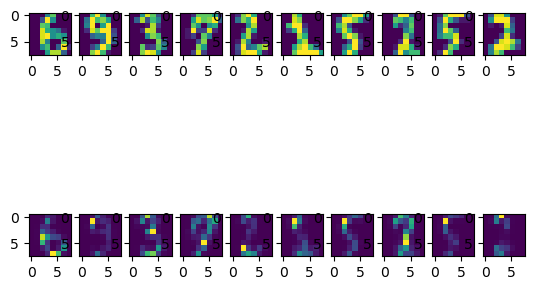

In [33]:
for i in range (10):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[i].reshape(8,8))
    
    plt.subplot(2, 10, i+1+10)
    plt.imshow(autoencoder.predict(X_test)[i].reshape(8,8))